In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [92]:
df = pd.read_csv("../data/1. raw/smoking_prediction.xlsx - smoking_prediction.csv")

In [93]:
# Veamos la distribución ( en porcentajes) de la cantiad de fumadores y no fumadores.
smoking_pct = (df_train["smoking"].value_counts(normalize=True)*100).round(2).astype(str) + "%" # Calculamos el porcentaje de cada clase de la columna smoking.


In [94]:
df.head()

,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
0,0,F,40,155,60,3.38,0.04,0.04,0.04,0.04,...,0.51,0.04,0.00,0.75,0.79,1.13,Y,0,Y,0
1,1,F,40,160,60,3.38,0.01,0.00,0.04,0.04,...,0.50,0.04,0.00,0.92,0.79,0.75,Y,0,Y,0
2,2,M,55,170,60,3.33,0.01,0.01,0.04,0.04,...,0.63,0.04,0.04,0.88,0.67,0.92,Y,0,N,1
3,3,M,40,165,70,3.67,0.05,0.05,0.04,0.04,...,0.59,0.04,0.04,0.79,1.08,0.75,Y,0,Y,0
4,4,F,40,155,60,3.58,0.04,0.04,0.04,0.04,...,0.50,0.04,0.00,0.67,0.58,0.92,Y,0,N,0


In [95]:
print(smoking_pct)

smoking
0    63.3%
1    36.7%
Name: proportion, dtype: object


C:\Users\PC\AppData\Local\Temp\ipykernel_35764\1159973449.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x="smoking",palette="Set2")


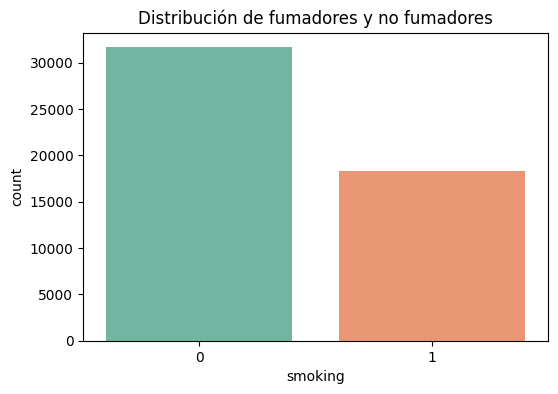

In [96]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x="smoking",palette="Set2")
plt.title("Distribución de fumadores y no fumadores")

plt.show()

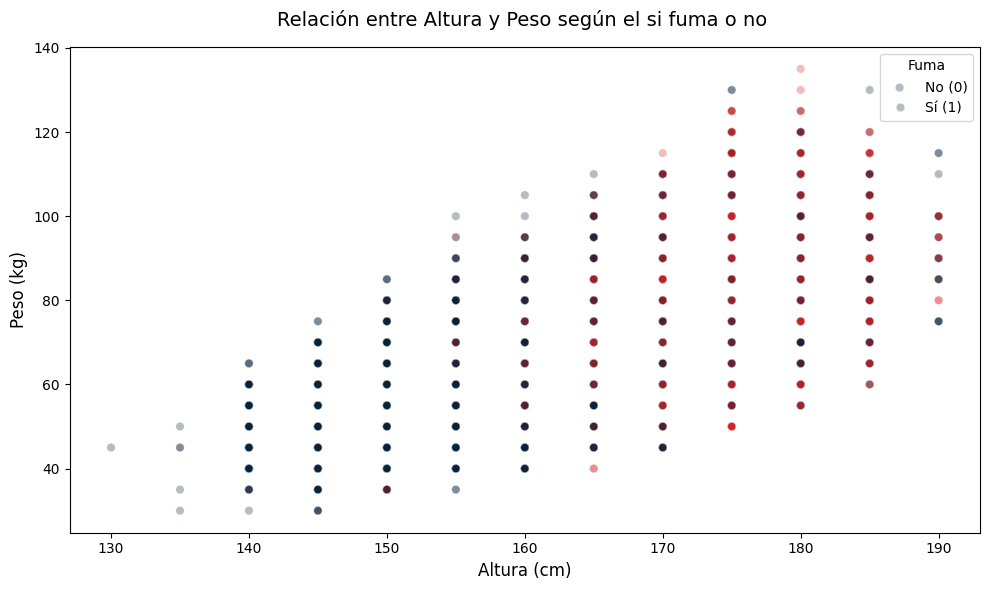

In [97]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x="height(cm)", 
    y="weight(kg)", 
    hue="smoking", 
    alpha=0.3, 
    palette={0: "#07223d", 1: "#d62728"}
)
plt.title("Relación entre Altura y Peso según el si fuma o no ", fontsize=14, pad=15)
plt.xlabel("Altura (cm)", fontsize=12)
plt.ylabel("Peso (kg)", fontsize=12)
plt.legend(title="Fuma", labels=["No (0)", "Sí (1)"])
plt.tight_layout()
plt.show()


In [98]:
gender_smoking_prop = pd.crosstab(df["gender"], df["smoking"], normalize="index") * 100

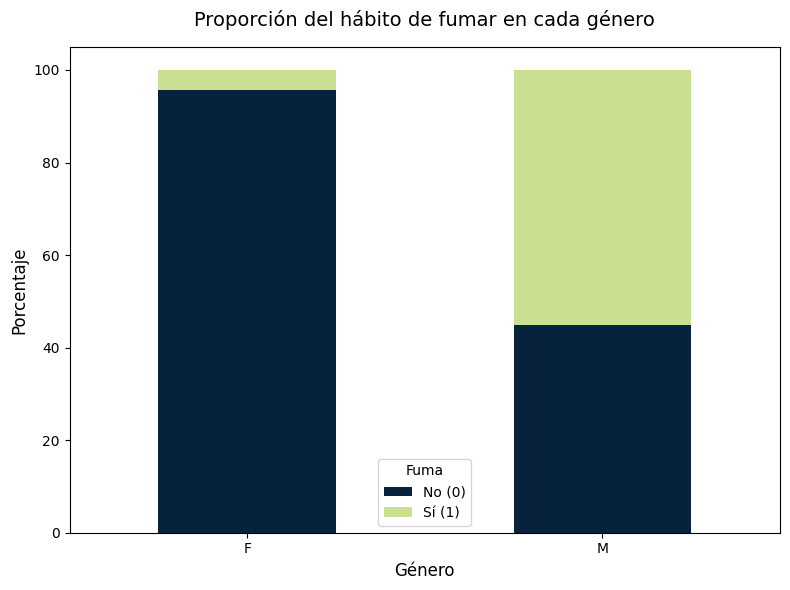

In [99]:

gender_smoking_prop.plot(kind="bar", stacked=True, figsize=(8, 6), color=["#07223d", "#cbdf90"]
)

plt.title("Proporción del hábito de fumar en cada género", fontsize=14, pad=15)
plt.xlabel("Género", fontsize=12)
plt.ylabel("Porcentaje", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Fuma", labels=["No (0)", "Sí (1)"])
plt.tight_layout()
plt.show()


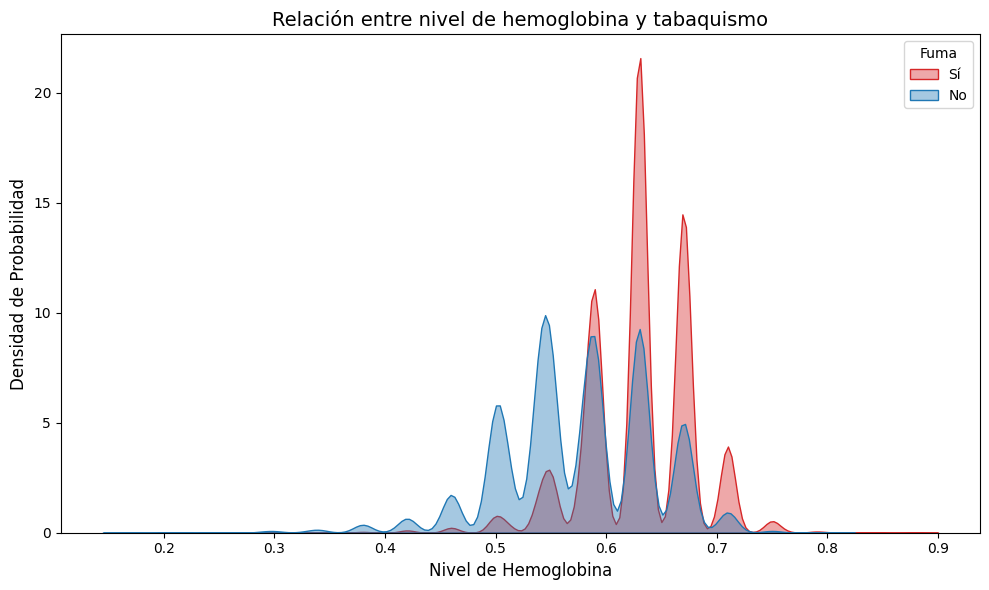

In [100]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="hemoglobin",hue="smoking", fill=True,common_norm=False,palette={0: "#1f77b4", 1: "#d62728"}, alpha=0.4
)
plt.title("Relación entre nivel de hemoglobina y tabaquismo", fontsize=14)
plt.xlabel("Nivel de Hemoglobina", fontsize=12)
plt.ylabel("Densidad de Probabilidad", fontsize=12)
plt.legend(title="Fuma", labels=["Sí", "No"])
plt.tight_layout()
plt.show()


C:\Users\PC\AppData\Local\Temp\ipykernel_35764\4043590287.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


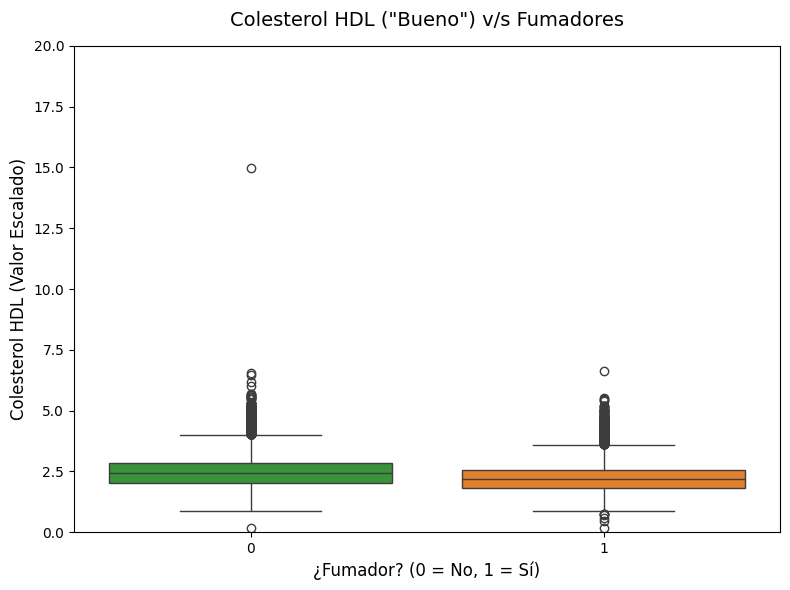

In [101]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df,x="smoking", y="HDL", palette={"0": "#2ca02c", "1": "#ff7f0e"}
)
plt.title("Colesterol HDL (\"Bueno\") v/s Fumadores", fontsize=14, pad=15)
plt.xlabel("¿Fumador? (0 = No, 1 = Sí)", fontsize=12)
plt.ylabel("Colesterol HDL (Valor Escalado)", fontsize=12)
plt.ylim(0, 20)
plt.tight_layout()
plt.show()


In [102]:
#Identifiquemos si hay correlación entre variables de nuestros Dataset. Para esto grafiquemos la matriz de correlación
corr=df.corr(numeric_only=True).round(2)

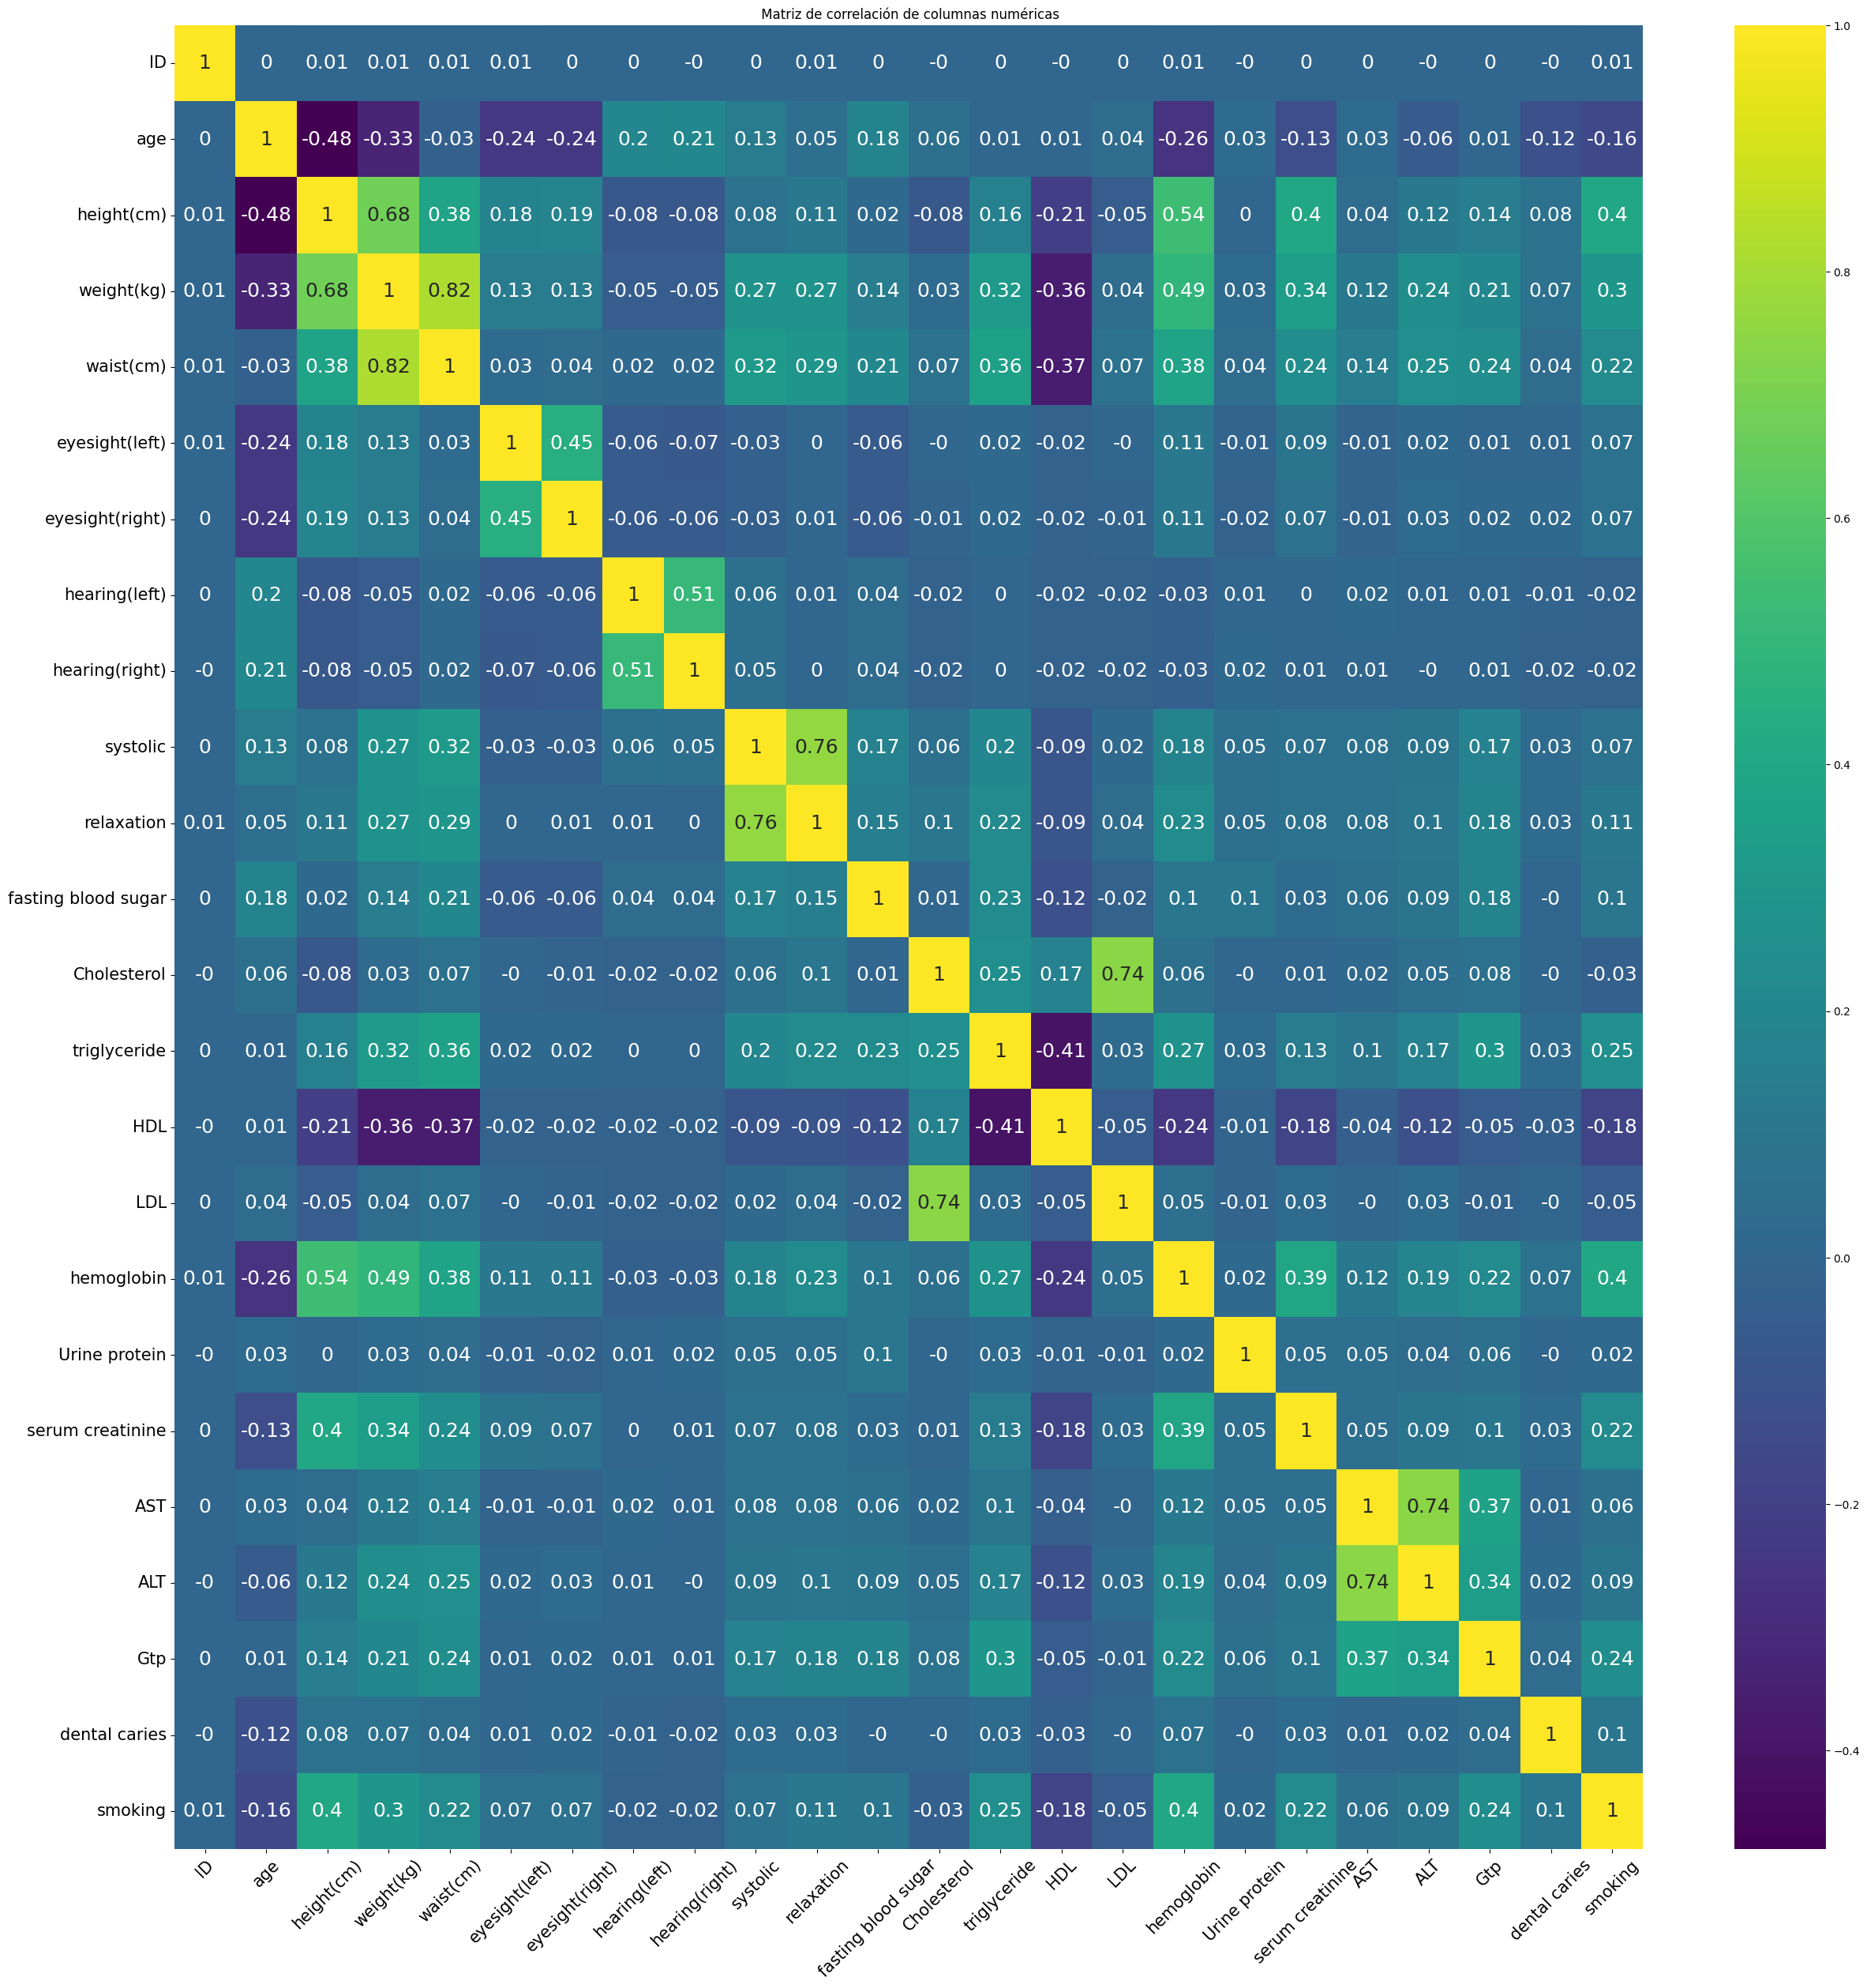

In [103]:
plt.figure(figsize=(30,30))
sns.heatmap(corr, annot=True, cmap="viridis", annot_kws={"size": 18})  # Grafica un mapa de calor 
plt.xticks(fontsize=15, rotation=45)
plt.yticks(fontsize=15)
plt.title(" Matriz de correlación de columnas numéricas")
plt.show()

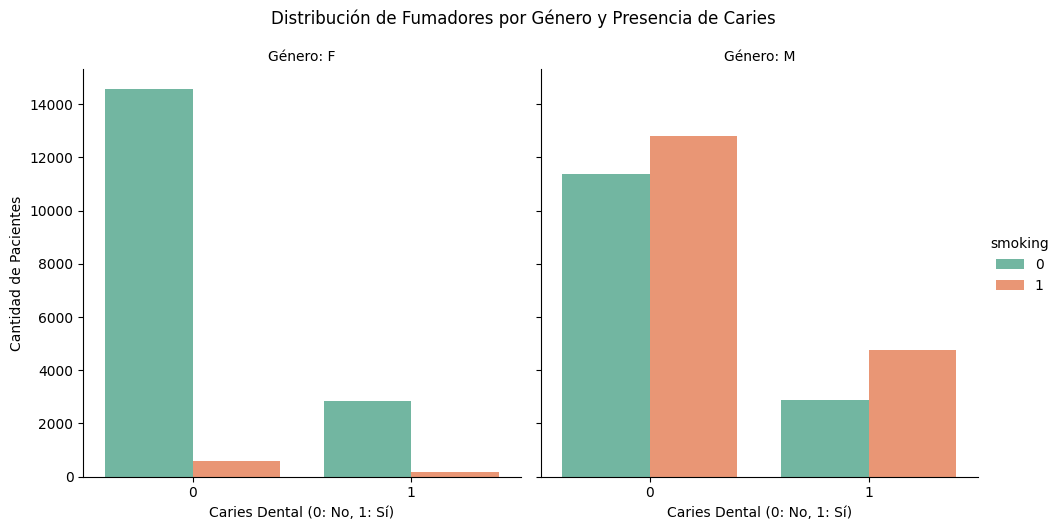

In [104]:
# Utilizamos catplot para añadir una tercera dimensión (columna="gender")
g = sns.catplot(
    data=df,
    x="dental caries",
    hue="smoking",
    col="gender",
    kind="count",  
    palette="Set2",
    height=5,
    aspect=1
)

g.fig.suptitle("Distribución de Fumadores por Género y Presencia de Caries", y=1.05)
g.set_axis_labels("Caries Dental (0: No, 1: Sí)", "Cantidad de Pacientes")
g.set_titles("Género: {col_name}")

plt.show()


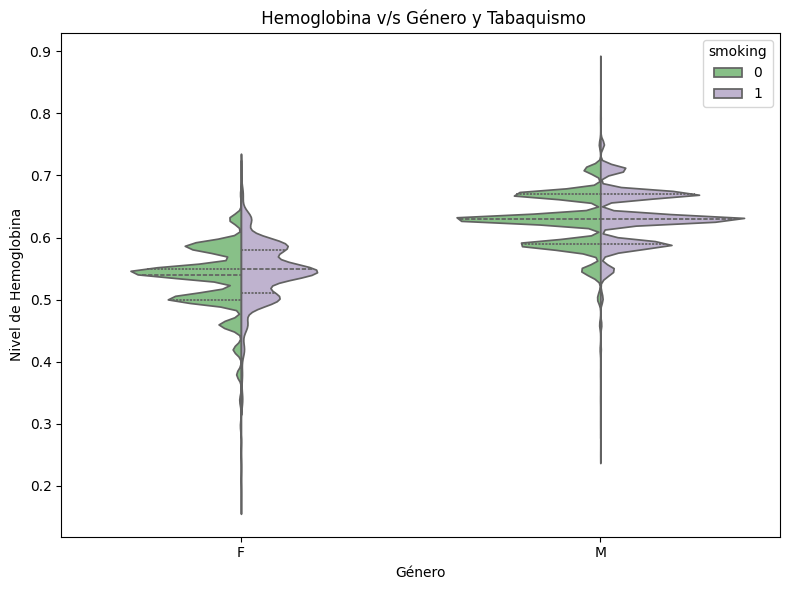

In [105]:
plt.figure(figsize=(8,6))
sns.violinplot(
    data=df,
    x="gender",
    y="hemoglobin",
    hue="smoking",
    split=True,
    inner="quartile",
    palette="Accent"
)

plt.title(" Hemoglobina v/s Género y Tabaquismo")
plt.ylabel("Nivel de Hemoglobina")
plt.xlabel("Género")

plt.tight_layout()
plt.show()
